# Mask Analysis

In [133]:
# Imports
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
import tifffile
from scipy.ndimage import median_filter
import pandas as pd
import function_definitions as source
from tqdm.notebook import tqdm
from scipy.ndimage import label

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data Loading
This notebook will load data from one population at a time and save in a .csv file in the same directory.

In [134]:
root = Path(r"C:\Users\jakub\Documents\Piotr\mask_analysis")

populations = ["merged_BC", "merged_BC_all_channels", "PC_merged_all"]

In [135]:
N = 0 # Population index

img_paths = sorted((root/"data"/"cell_images"/populations[N]).rglob("*.ome.tif"))
cellpose_paths = sorted((root/"data"/"cellpose_masks"/populations[N]).rglob("*.npy"))
nucleus_paths = sorted((root/"data"/"nuclear_masks"/populations[N]).rglob("*.tif"))

assert len(img_paths) == len(cellpose_paths) == len(nucleus_paths)

number_of_images = len(img_paths)
print(f"{number_of_images} images detected.")

260 images detected.


We will store mask and cell data in the following manner

|Population|Image id|Cell id|Cellpose Area|Nucleus Area|Nucleus/Cellpose|Average Nucleus Signal|Circularity 1|Circularity 2|Eccentricity|
|---|---|---|---|---|---|---|---|---|---|
| - | - | * | - | - | - | - | - | - | - |

>The circularities will be calculated using the following formulas

$\text{Circularity 1} = \frac{4\pi \cdot Area}{Perimeter^2}$

$\text{Circularity 2} = \frac{Area}{Convex Area}$

>Eccentricity measures the eccentricity of an ellipse with the same second moments. The closer its value is to zero, the closer the shape resembles a perfect circle.

**There can be multiple cells in an image hence different ids*

In [136]:
rows = []

for n in tqdm(range(number_of_images)):
    tiff = tifffile.imread(img_paths[n])
    cellpose_mask = np.load(cellpose_paths[n], allow_pickle=True).item()['masks']
    nuclear_mask = tifffile.imread(nucleus_paths[n])

    if nuclear_mask.ndim == 3:
        nuclear_mask = nuclear_mask[0]

    # We want to treat splitting/closely agregated cells as singular events, not separate cells
    events_binary_mask = (nuclear_mask * cellpose_mask) > 0
    events_mask = measure.label(events_binary_mask, connectivity=1)
    events_mask = source.remove_small_labels(events_mask, min_size=110, connectivity=1, relabel=True)

    number_of_events = source.number_of_objects(events_mask)


    # Assumes brightfield on the 1st slide and DAPI stain on the 5th one
    brightfield_channel = median_filter(tiff[0], size=3)
    dapi_channel = median_filter(tiff[4], size=3)

    if number_of_events == 0:
        continue
    
    for EventID in range(number_of_events):
        event_mask = np.where(events_mask==EventID+1, 1, 0).astype(bool)

        # Tracking original Cellpose's IDs
        overlapping_ids = np.unique(cellpose_mask[event_mask])
        overlapping_ids = overlapping_ids[overlapping_ids != 0]
        n_contributing_cells = len(overlapping_ids)

        # Area of the cellpose (cytoplasm) masks over the given nuclear signature
        cellpose_area = np.isin(cellpose_mask, overlapping_ids).sum()

        # Area of the nuclear signature inside of the cellpose mask
        nuc_area = event_mask.sum()

        nuc_by_cell_area = nuc_area / cellpose_area if cellpose_area > 0 else np.nan

        # Mean intensity of the DAPI signal
        nuc_mean = dapi_channel[event_mask].mean() if event_mask.any() else np.nan

        # Circularity measures
        circularity1, circularity2, eccentricity = source.circularity_measures(event_mask)


        # Pandas DataFrame formatting
        rows.append({
            "Population": populations[N],
            "Image ID": n,
            "Event ID": EventID,
            "N Contributing Cellpose Cells": n_contributing_cells,
            "Cellpose Area": cellpose_area,
            "Nucleus Area": nuc_area,
            "Nucleus/Cellpose": nuc_by_cell_area,
            "Average Nucleus Signal": nuc_mean,
            "Circularity 1": circularity1,
            "Circularity 2": circularity2,
            "Eccentricity": eccentricity
            })
        

df = pd.DataFrame(rows)     
df.to_csv(f"{populations[N]}.csv")

  0%|          | 0/260 [00:00<?, ?it/s]

<string>:2: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
c:\Users\jakub\AppData\Local\Programs\Python\Python311\Lib\site-packages\skimage\_shared\utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)


# Comparison of the Circularity Measures Distributions

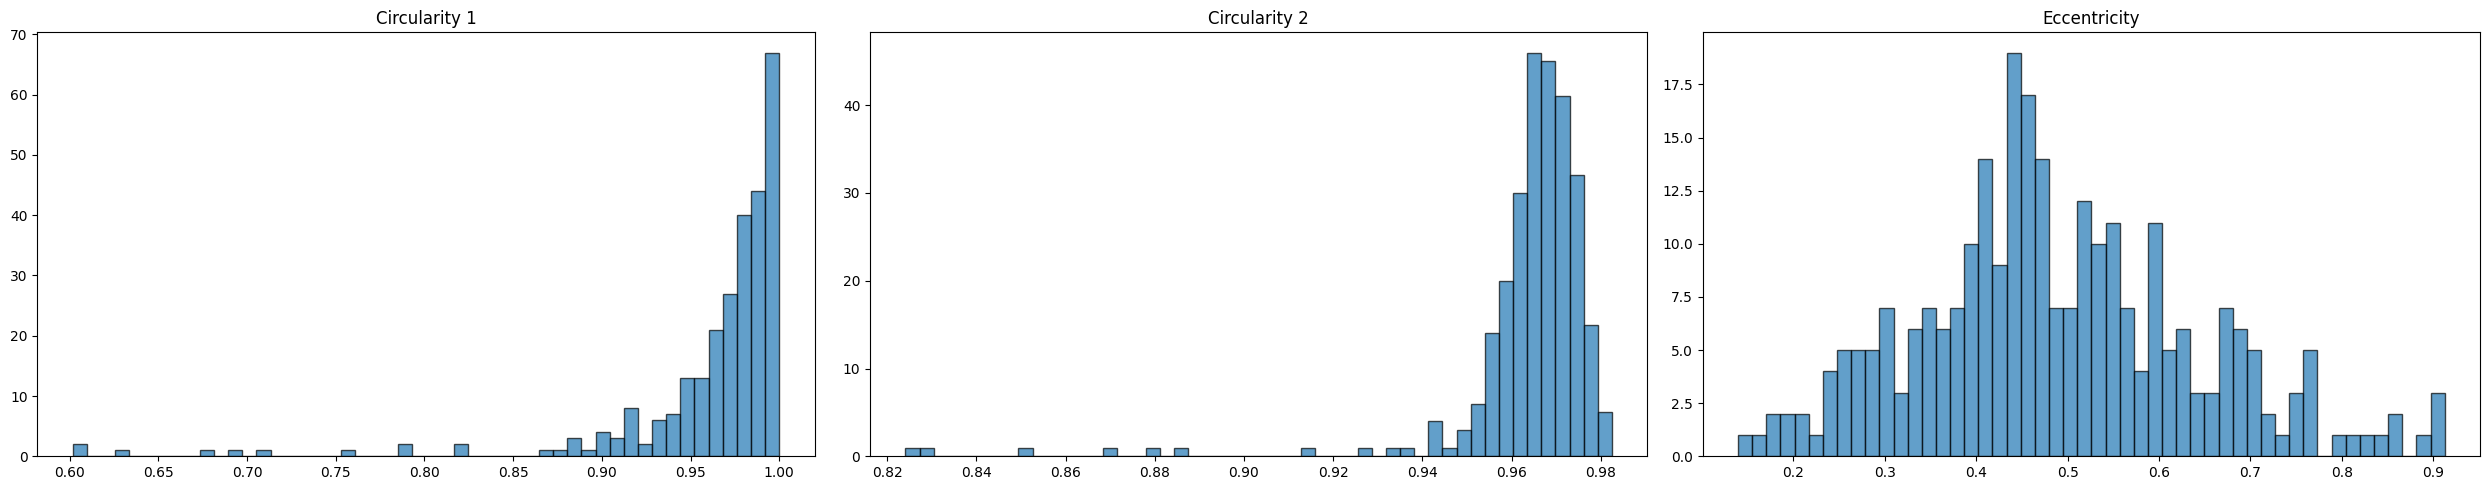


      Circularity 1 mass below 0.92: 0.11397058823529412		Circularity 2 mass below 0.956: 0.1213235294117647		Eccentricity mass above 0.7: 0.09191176470588236



In [137]:
fig, ax = plt.subplots(1, 3, figsize=(25, 5))

ax[0].set_title("Circularity 1")
ax[0].hist(df["Circularity 1"].dropna(), bins=50, edgecolor='black', alpha=0.7)

ax[1].set_title("Circularity 2")
ax[1].hist(df["Circularity 2"].dropna(), bins=50, edgecolor='black', alpha=0.7)

ax[2].set_title("Eccentricity")
ax[2].hist(df["Eccentricity"].dropna(), bins=50, edgecolor='black', alpha=0.7)

plt.tight_layout()
plt.show()

circ1_th, circ2_th, ecc_th = 0.92, 0.956, 0.7

mass_below_circ1 = (df["Circularity 1"] < circ1_th).sum() / len(df["Circularity 1"])
mass_below_circ2 = (df["Circularity 2"] < circ2_th).sum() / len(df["Circularity 2"])
mass_above_ecc = (df["Eccentricity"] > ecc_th).sum() / len(df["Eccentricity"])

print(f"""
      Circularity 1 mass below {circ1_th}: {float(mass_below_circ1)}\t\tCircularity 2 mass below {circ2_th}: {float(mass_below_circ2)}\t\tEccentricity mass above {ecc_th}: {float(mass_above_ecc)}
""")

Given the above histograms, we will choose the following cutoff values so the chosen subpopulation will be around 10%:
$\begin{equation}\text{max circularity 1} = 0.92\end{equation}$
$\begin{equation}\text{max circularity 2} = 0.956\end{equation}$
$\begin{equation}\text{min eccentricity} = 0.7\end{equation}$

All events with one of the scores above or below the certain threshold will be classified as non-circular.

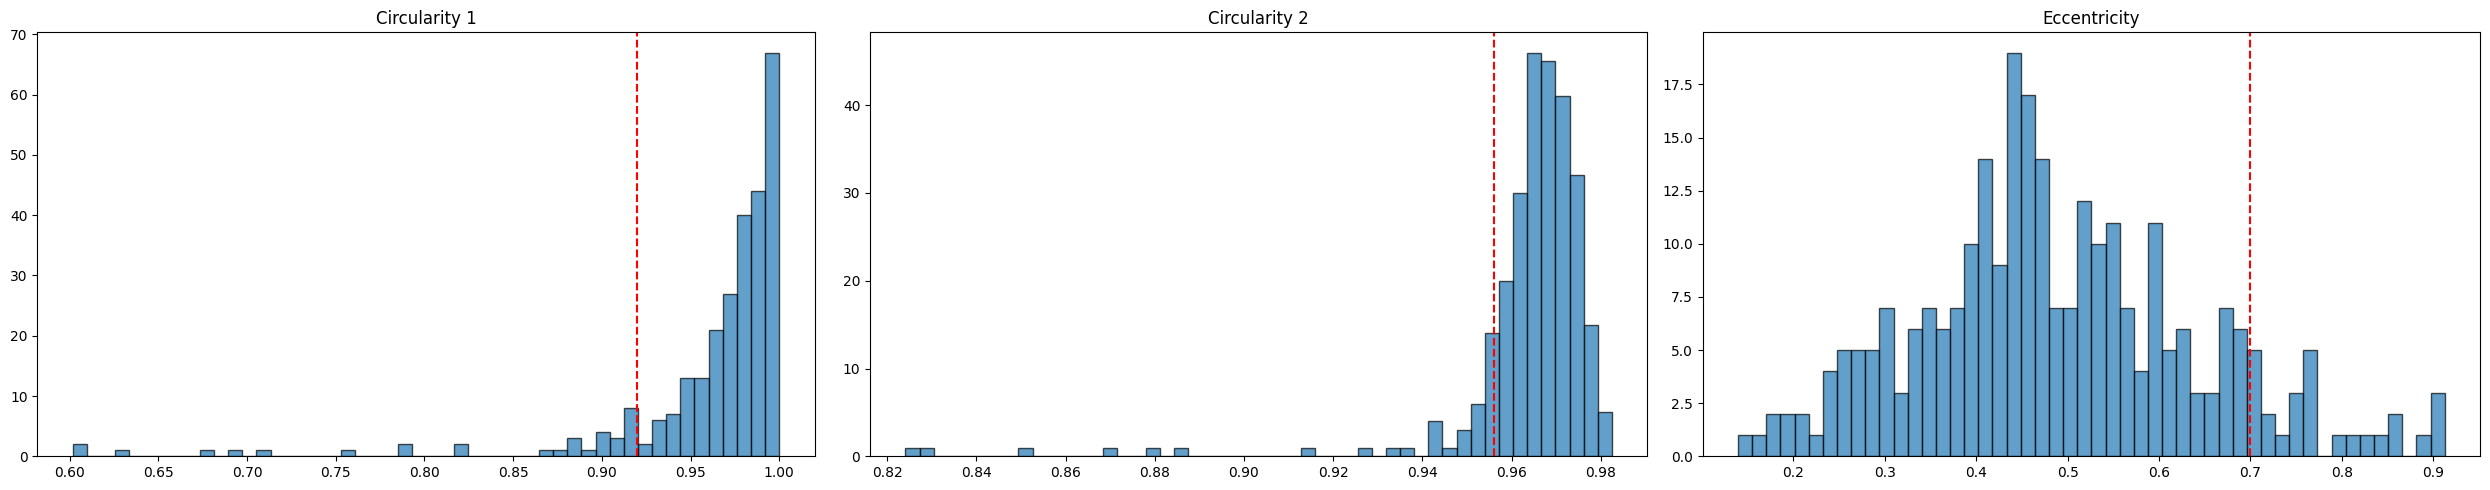

In [138]:
fig, ax = plt.subplots(1, 3, figsize=(25, 5))

ax[0].set_title("Circularity 1")
ax[0].hist(df["Circularity 1"].dropna(), bins=50, edgecolor='black', alpha=0.7)
ax[0].axvline(circ1_th, color='r', linestyle='--')

ax[1].set_title("Circularity 2")
ax[1].hist(df["Circularity 2"].dropna(), bins=50, edgecolor='black', alpha=0.7)
ax[1].axvline(circ2_th, color='r', linestyle='--')

ax[2].set_title("Eccentricity")
ax[2].hist(df["Eccentricity"].dropna(), bins=50, edgecolor='black', alpha=0.7)
ax[2].axvline(ecc_th, color='r', linestyle='--')

plt.tight_layout()
plt.show()

# Finding the noncircular Events

In [139]:
non_circulars = df[(df["Circularity 1"] < circ1_th) | (df["Circularity 2"] < circ2_th) | (df["Eccentricity"] > ecc_th)]

unique_imgs = np.unique(non_circulars.iloc[:, 1])

print(f"Noncircular events found in {len(unique_imgs)} unique images.")

Noncircular events found in 49 unique images.


## Copying files with images of interest

In [140]:
import shutil

out_dir = Path(r".\non_circulars")/populations[N]
out_dir.mkdir(exist_ok=True, parents=True)

for image_id in tqdm(unique_imgs, "Copying Files"):
    tif_path = img_paths[image_id]
    shutil.copy2(tif_path, out_dir)

Copying Files:   0%|          | 0/49 [00:00<?, ?it/s]

***
# DAPI stain analysis
Next we will analyse DAPI stain signal intensities as well as the share of cell area covered by the nucleus.

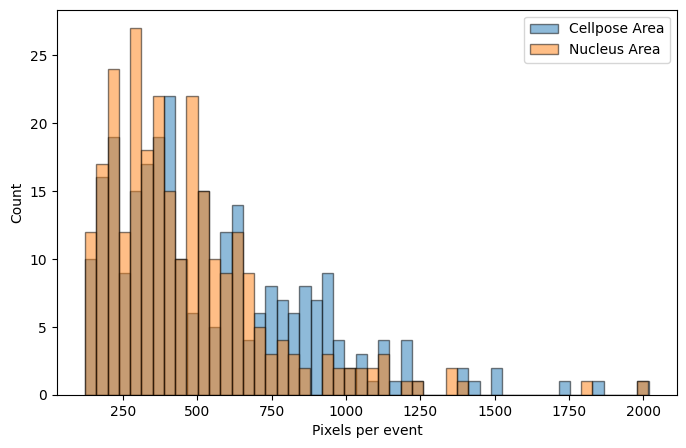

In [144]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["Cellpose Area"].dropna(), bins=50, alpha=0.5, label="Cellpose Area", edgecolor='black')
ax.hist(df["Nucleus Area"].dropna(), bins=50, alpha=0.5, label="Nucleus Area", edgecolor='black')
ax.set_xlabel("Pixels per event")
ax.set_ylabel("Count")
ax.legend()
plt.show()

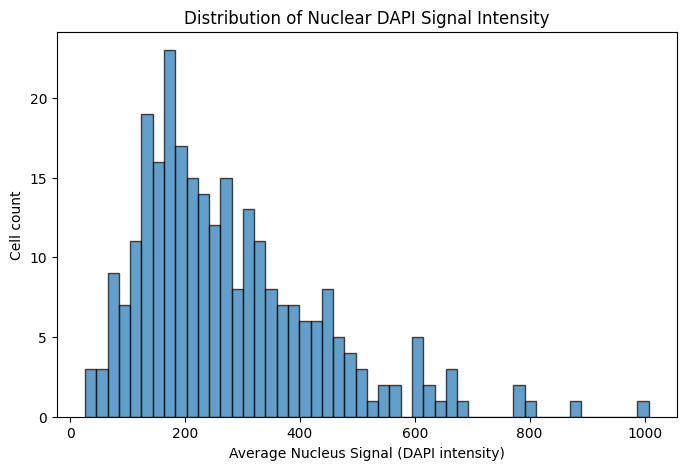

In [141]:
plt.figure(figsize=(8, 5))
plt.hist(df["Average Nucleus Signal"].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("Average Nucleus Signal (DAPI intensity)")
plt.ylabel("Cell count")
plt.title("Distribution of Nuclear DAPI Signal Intensity")
plt.show()

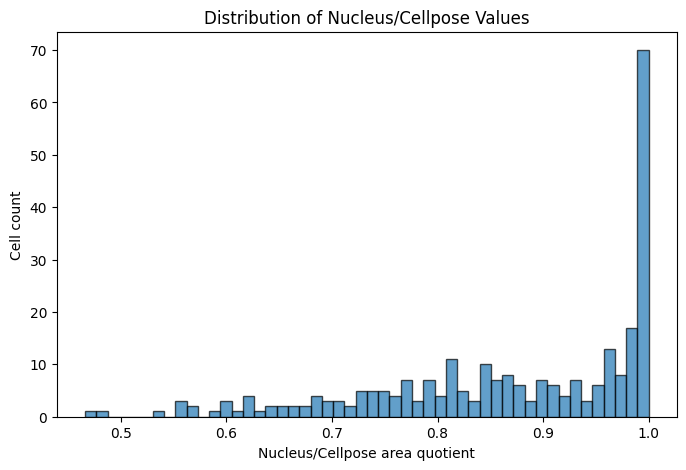

In [142]:
plt.figure(figsize=(8, 5))
plt.hist(df["Nucleus/Cellpose"].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("Nucleus/Cellpose area quotient")
plt.ylabel("Cell count")
plt.title("Distribution of Nucleus/Cellpose Values")
plt.show()

The disproportional number of 1.0 values is due to some masks being bigger than the cells themselves. I intentionally capped the value at one, but printed (cell 7 output) all cells for which this ratio would exceed 1.1. If there is no information, it means that no cells exceeded this threshold.

## Open items
- Control/non-control labeling for BC and PC populations not yet available; 
  `Condition` column is placeholder ("unknown") pending info from [collaborator].